<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Parametric_Amplification_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

### This notebook starts with some simple plots to visualize amplification typically performed by superconducting, quantum-limited parametric amplifiers. It then progresses to simulation plots for a slightly more realistic output.

The exploration of superconducting quantum devices demands precise numerical simulations to visualize wave propagation dynamics because the fundamental operational mechanism relies inherently upon the nondissipative nonlinearity originating from the Josephson junction (JJ). The macroscopic quantum behavior of this discrete superconducting weak link produces a purely dispersive response, which is governed by the standard Josephson relations for the supercurrent $I$ and the voltage $V$, explicitly given by $I = I_c \sin(\varphi)$ and $V = \frac{\Phi_0}{2\pi} \frac{d\varphi}{dt}$, where $I_c$ represents the critical current, $\Phi_0$ denotes the magnetic flux quantum, and $\varphi$ signifies the superconducting phase difference across the junction. Taking the temporal derivative of the supercurrent reveals a phase dependent dynamic inductance defined by $L_J(\varphi) = \frac{\Phi_0}{2\pi I_c \cos(\varphi)}$. Expanding this inductive term via a Taylor series generates the essential higher order electrical nonlinearities that mediate continuous energy exchange among interacting propagating modes or localized cavity resonances. Utilizing this physical mechanism, a Josephson Traveling Wave Parametric Amplifier (JTWPA) facilitates the spatial mixing of microwaves along a transmission line, transferring energy from a high power pump wave to a weaker signal wave while concurrently generating an idler wave. The continuous spatial evolution of these complex wave amplitudes is modeled through Coupled Mode Theory (CMT), employing Ordinary Differential Equations (ODEs) across the spatial propagation distance $z$. The primary variables include the complex slowly varying signal amplitude $A_s(z)$, the complex slowly varying idler amplitude $A_i(z)$, the parametric coupling strength $\kappa$, and the phase mismatch $\Delta k$. Conversely, a Josephson Parametric Amplifier (JPA) operates as a localized resonant cavity, which is mathematically represented in the time domain $t$ as a driven, damped harmonic oscillator featuring a modulated kinetic inductance. The governing parameters for the localized cavity include the resonant angular frequency $\omega_0$, the dissipative damping rate $\gamma$, and the fractional modulation depth $\lambda$.

The governing coupled mode equations for the spatial envelope evolution are formulated below.

$$ \frac{dA_s(z)}{dz} = i \kappa A_i^*(z) e^{-i \Delta k z} $$

$$ \frac{dA_i^*(z)}{dz} = -i \kappa A_s(z) e^{i \Delta k z} $$

The parametric amplification of the intracavity flux $\Phi(t)$ relies on the following classical Mathieu equation.

$$ \frac{d^2\Phi(t)}{dt^2} + \gamma \frac{d\Phi(t)}{dt} + \omega_0^2 (1 + \lambda \cos(2\omega_0 t)) \Phi(t) = 0 $$

In summary, the foundational nonlinearity of the Josephson junction dynamic inductance provides the essential wave mixing physical basis required to accurately parameterize both the spatial signal growth and the temporal resonant cavity modulation.

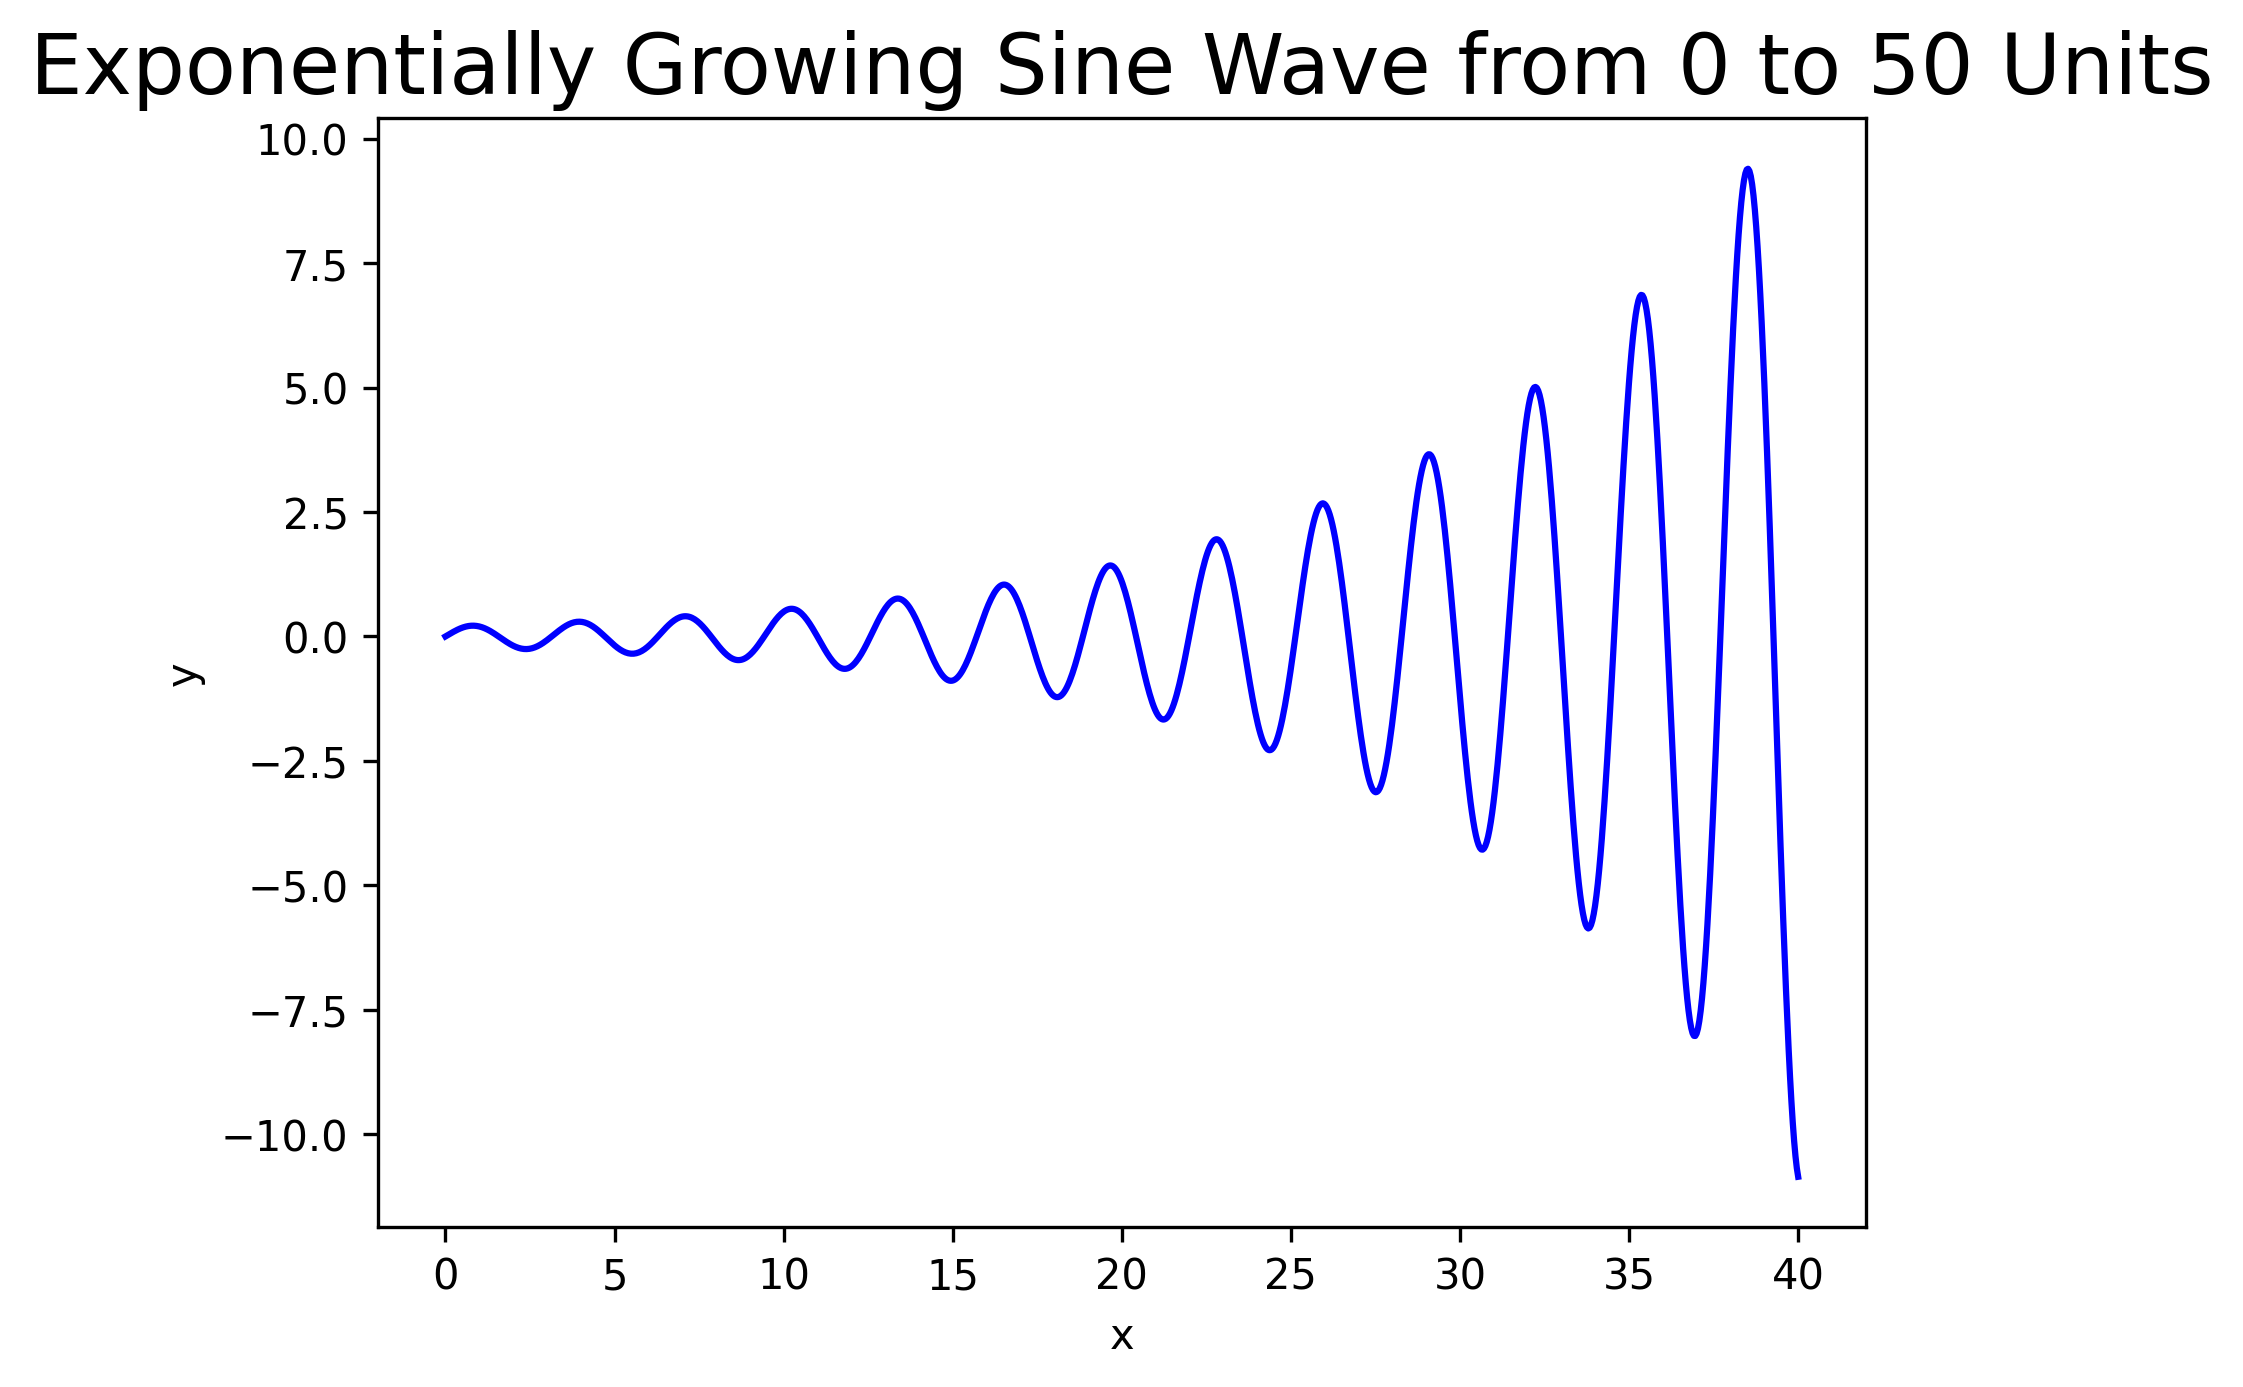

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.1 * x)       # Start at 0.2 and grow exponentially
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()


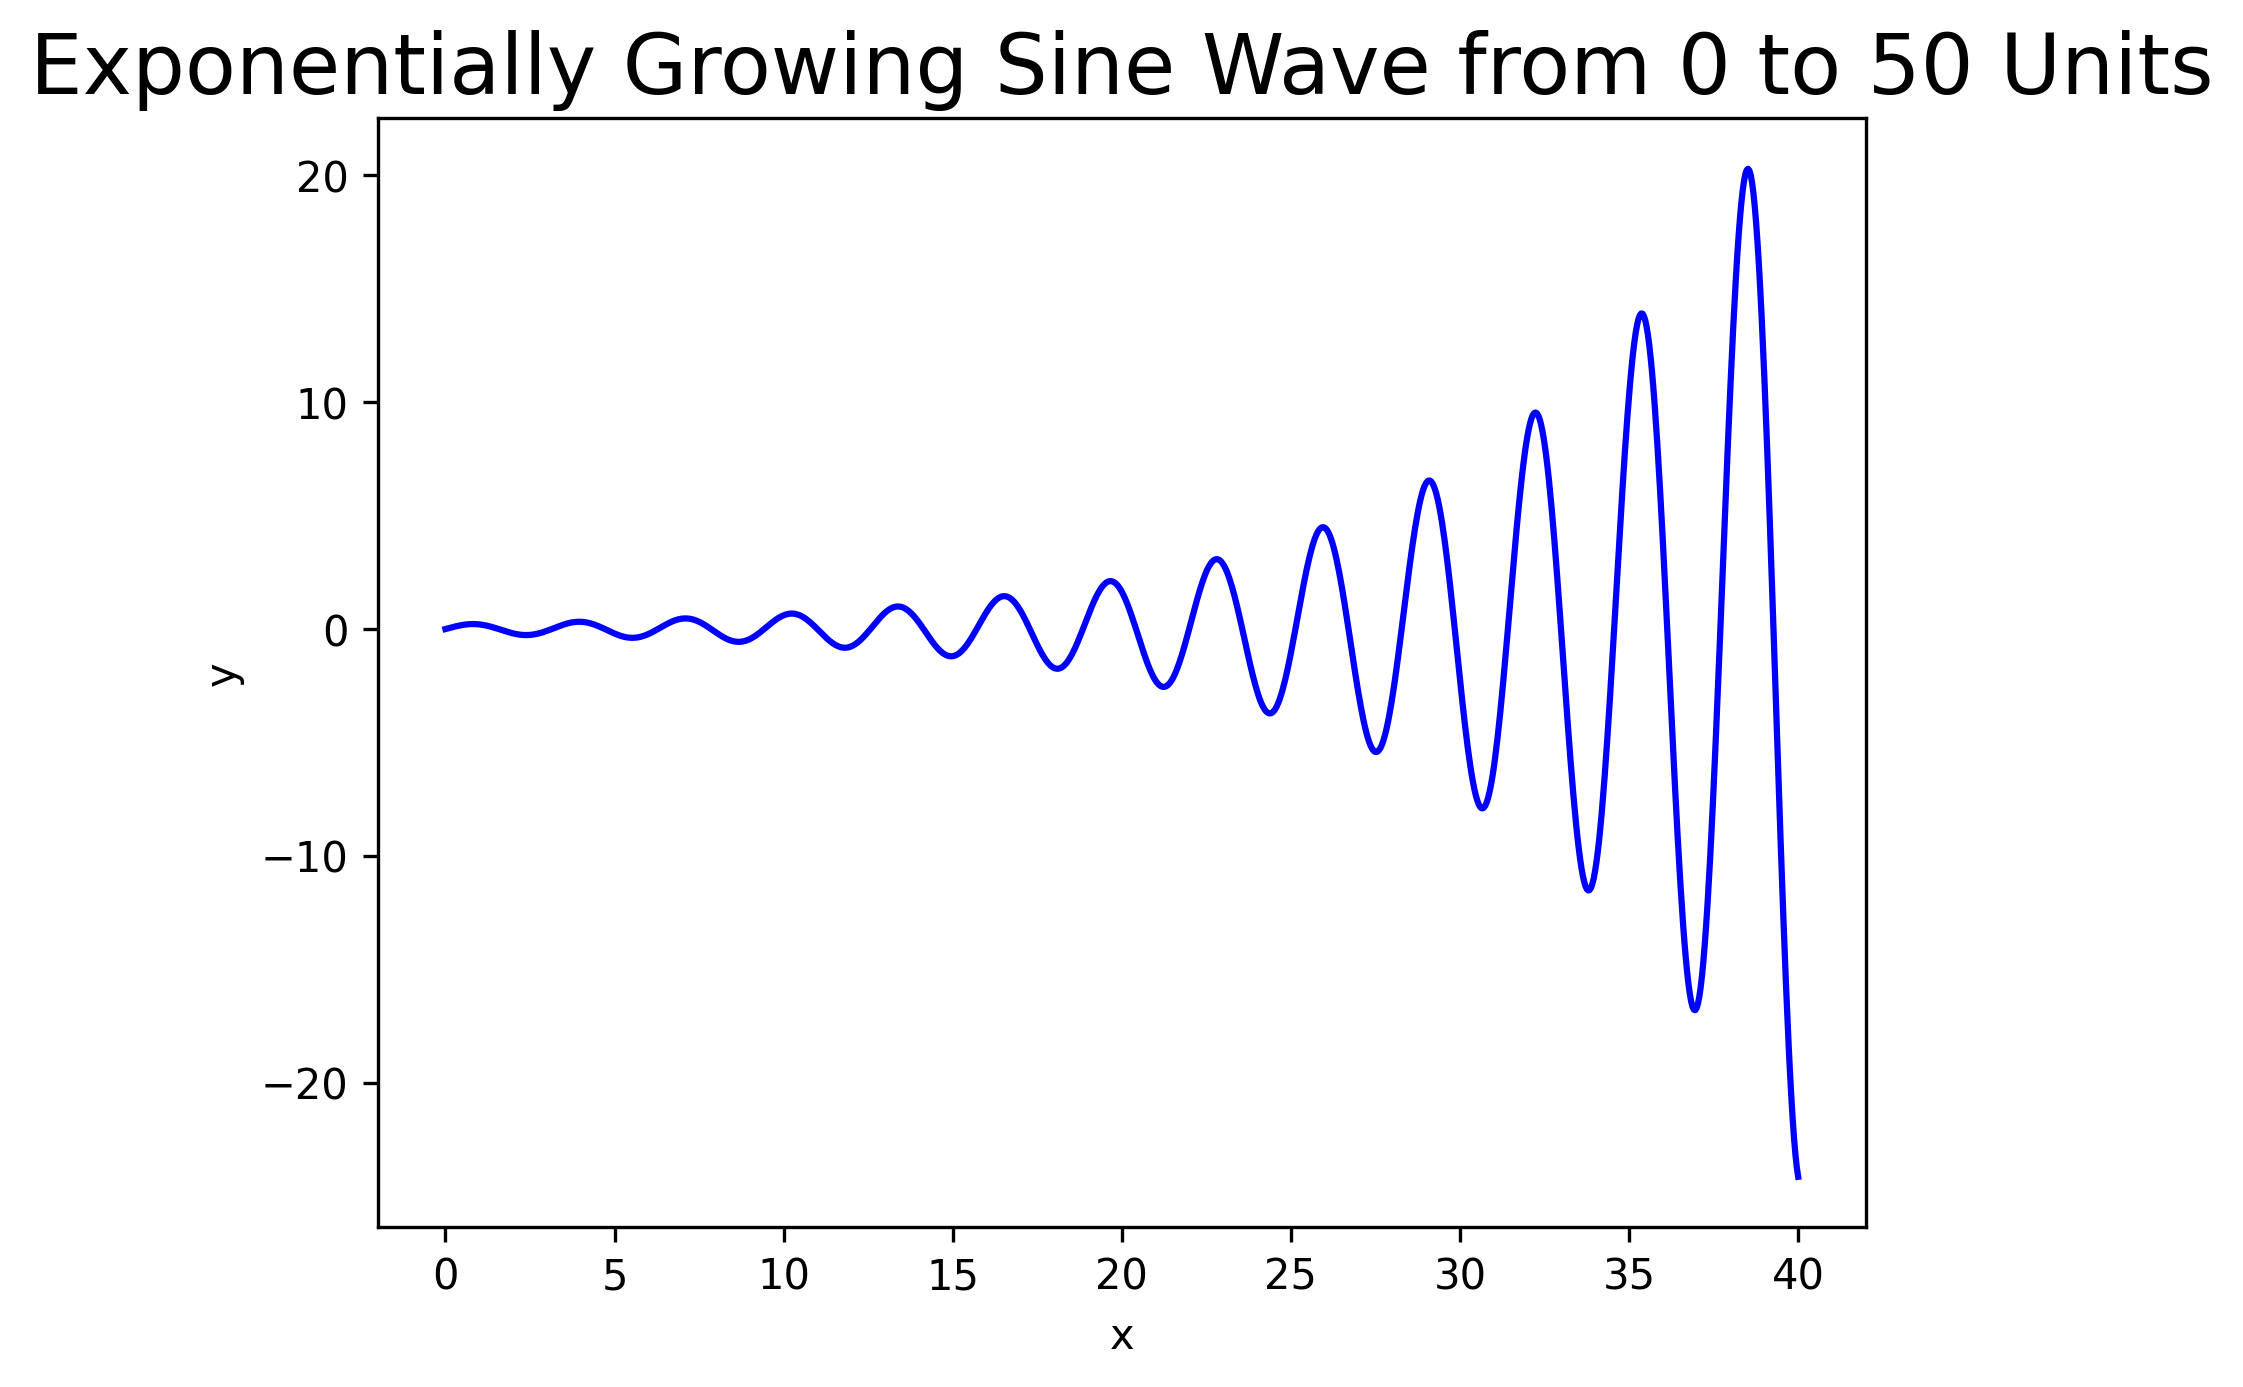

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.12 * x)       # Start at 0.2 and grow exponentially at a different rate
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()

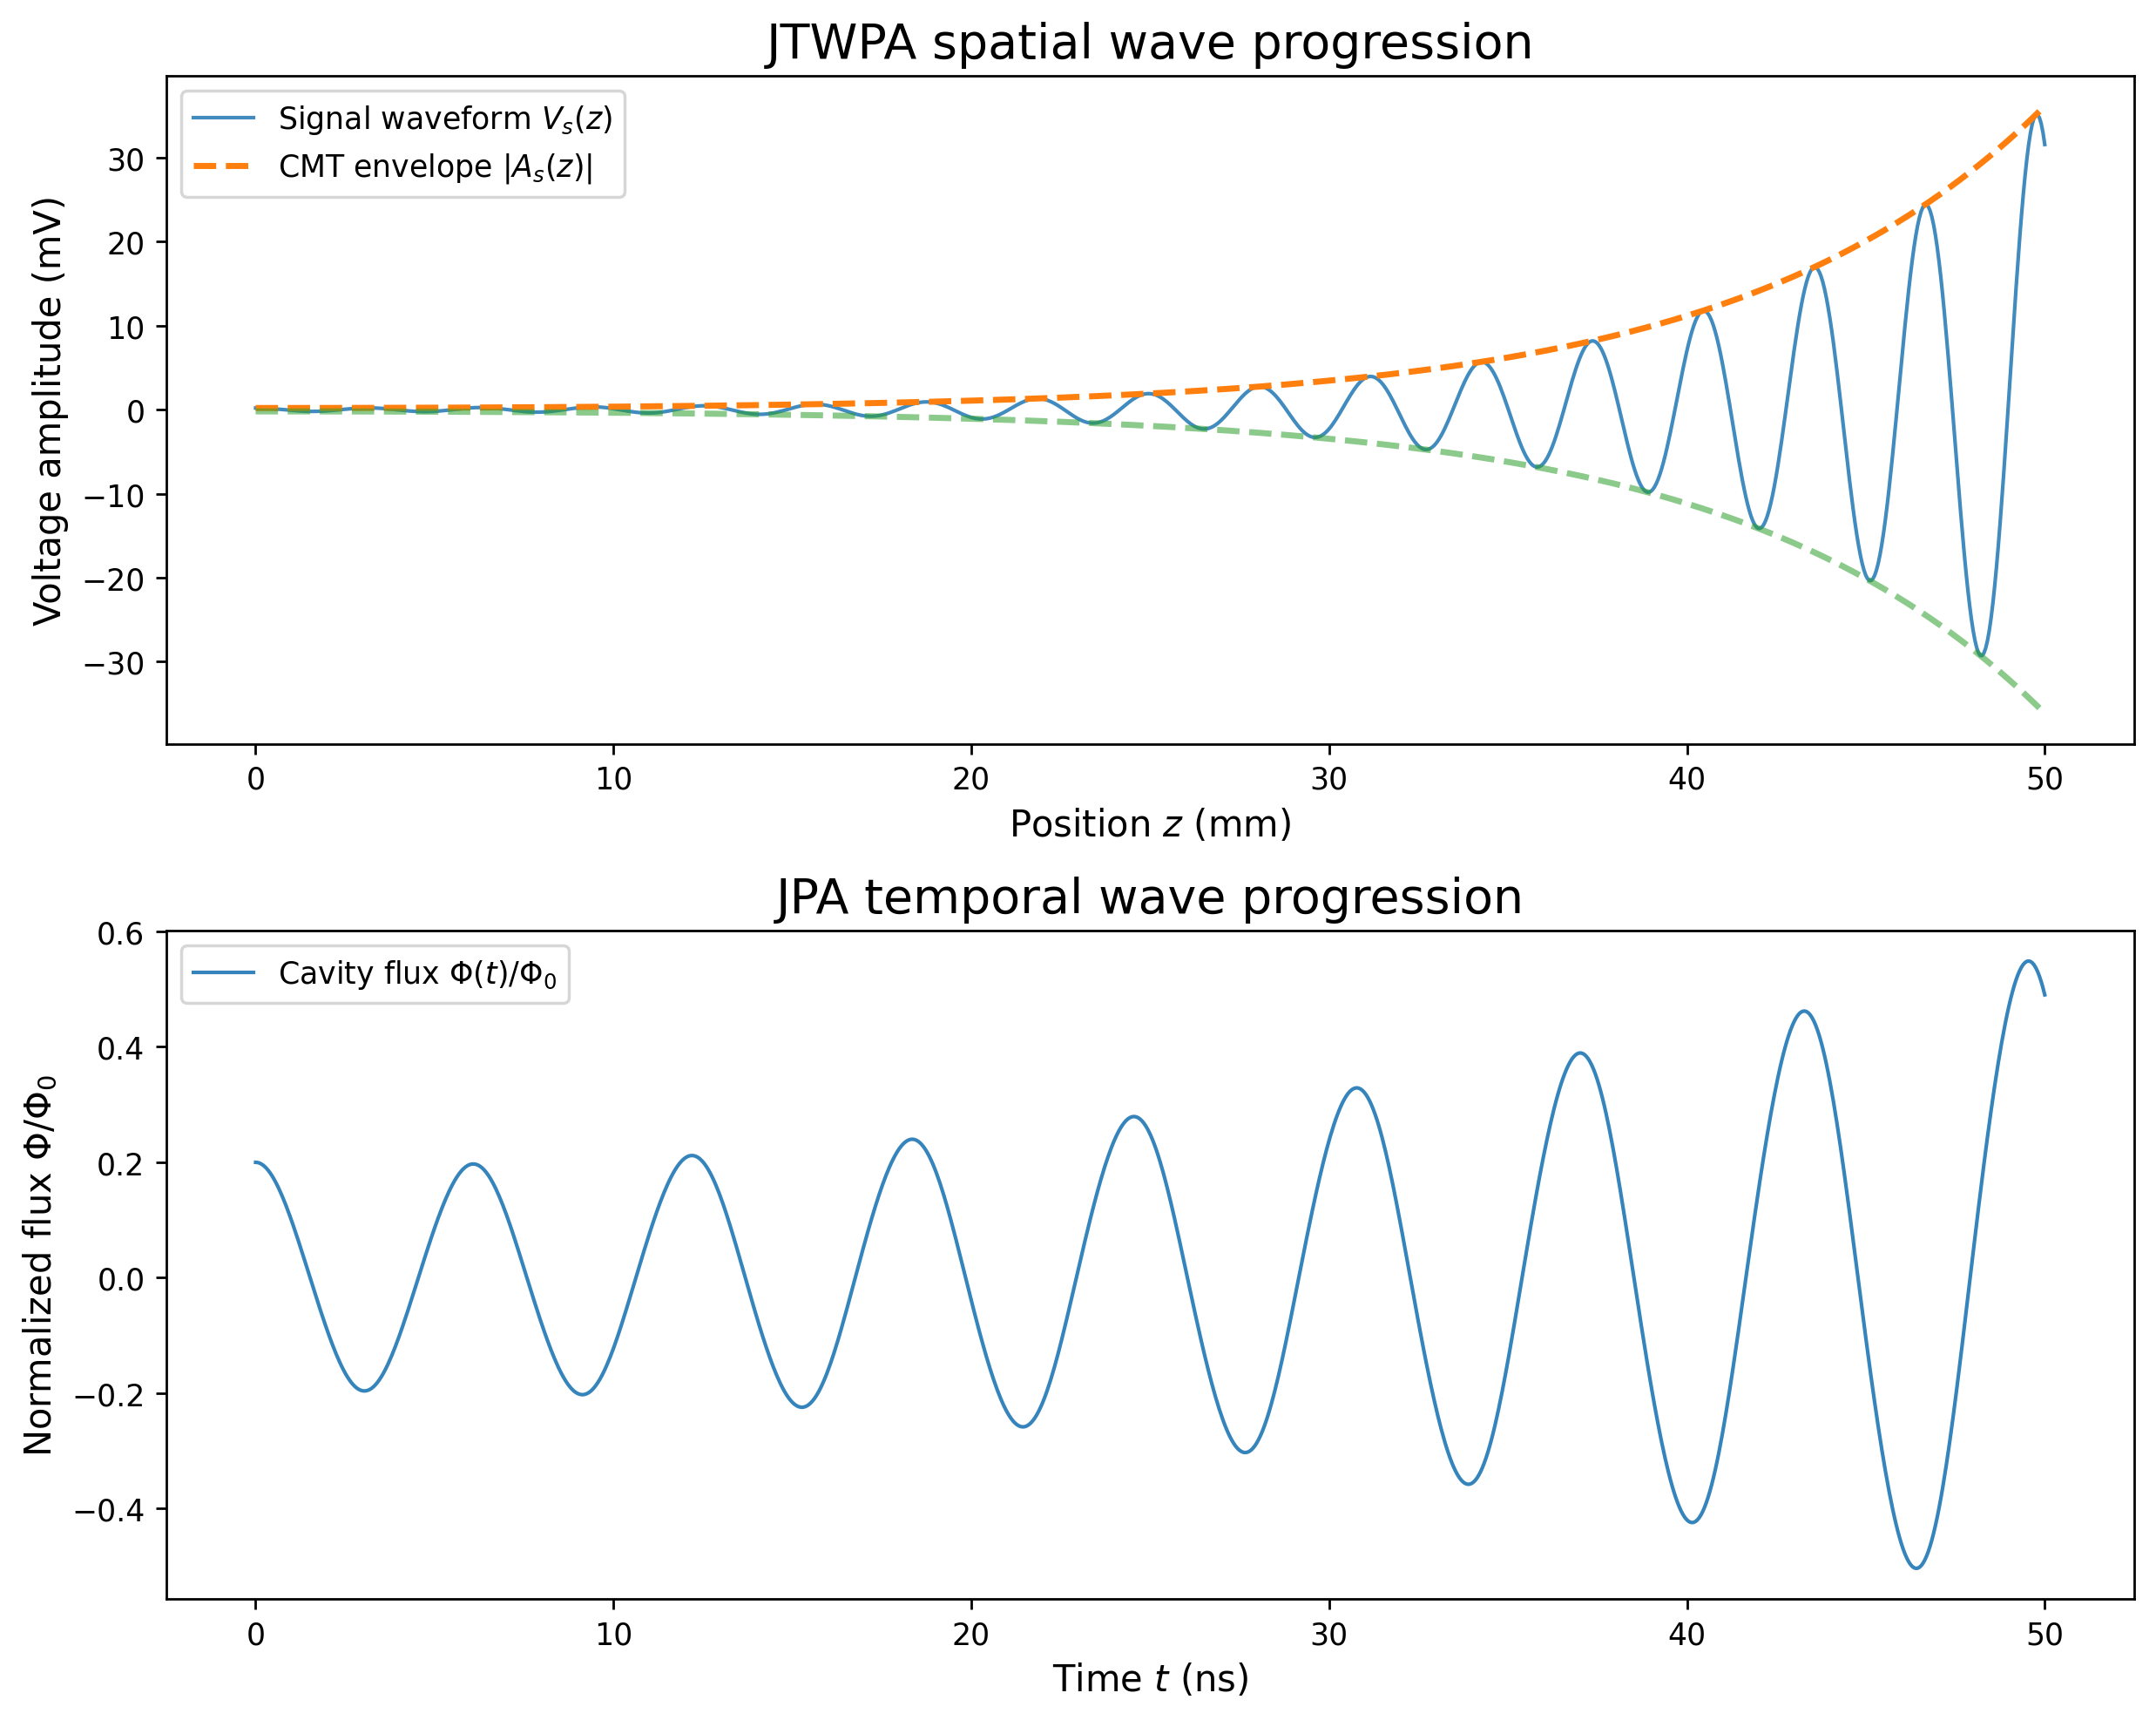

In [10]:
# !uv pip install -q numpy scipy matplotlib

"""
Simulation of superconducting parametric amplifiers.

This script integrates a spatial Coupled Mode Theory model for a Josephson
Traveling Wave Parametric Amplifier and a temporal Mathieu-type oscillator
model for a Josephson Parametric Amplifier.

Unit conventions
----------------
JTWPA:
    Position is measured in millimeters.
    Coupling and phase mismatch are measured per millimeter.
    Signal and idler amplitudes are measured in millivolts.

JPA:
    Time is measured in nanoseconds.
    Angular frequency is measured in radians per nanosecond.
    Damping is measured per nanosecond.
    Flux is normalized to the superconducting flux quantum Phi_0.
"""

from dataclasses import dataclass
from typing import Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from scipy.integrate import solve_ivp


# =============================================================================
# CONTROL KNOBS WITH UNITS
# =============================================================================

# Numerical sampling controls
NUM_EVALUATION_POINTS = 1_000
SOLVER_RELATIVE_TOLERANCE = 1.0e-8
JTWPA_ABSOLUTE_TOLERANCE_MV = 1.0e-10
JPA_ABSOLUTE_TOLERANCE = 1.0e-10

# Plot controls
MPL_DPI = 250
FIGURE_SIZE_IN = (10.0, 8.0)
LINE_WIDTH_THIN = 1.2
LINE_WIDTH_THICK = 2.0

# JTWPA spatial-domain controls
JTWPA_LENGTH_MM = 50.0
JTWPA_KAPPA_PER_MM = 0.12
JTWPA_DELTA_K_RAD_PER_MM = 0.05
JTWPA_SIGNAL_INIT_MV = 0.2
JTWPA_IDLER_CONJ_INIT_MV = 0.0
JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM = 2.0

# JPA temporal-domain controls
JPA_DURATION_NS = 50.0
JPA_OMEGA_0_RAD_PER_NS = 1.0
JPA_DAMPING_RATE_PER_NS = 0.02
JPA_MODULATION_DEPTH_DIMENSIONLESS = 0.15
JPA_FLUX_INIT_PHI0 = 0.2
JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS = 0.0


@dataclass(frozen=True)
class JtwpaParameters:
    """Store JTWPA model parameters with explicit units."""

    length_mm: float
    kappa_per_mm: float
    delta_k_rad_per_mm: float
    signal_init_mv: float
    idler_conj_init_mv: float
    carrier_wave_vector_rad_per_mm: float


@dataclass(frozen=True)
class JpaParameters:
    """Store JPA model parameters with explicit units."""

    duration_ns: float
    omega_0_rad_per_ns: float
    damping_rate_per_ns: float
    modulation_depth_dimensionless: float
    flux_init_phi0: float
    flux_derivative_init_phi0_per_ns: float


def configure_matplotlib() -> None:
    """Apply high-resolution plotting defaults."""

    mpl.rcParams.update(
        {
            "figure.dpi": MPL_DPI,
            "font.sans-serif": ["Tahoma", "DejaVu Sans"],
            "font.weight": "normal",
            "axes.titleweight": "normal",
            "axes.titlesize": 16,
            "axes.labelsize": 12,
            "legend.fontsize": 10,
        }
    )


def compute_jtwpa_derivatives(
    position_mm: float,
    state_mv: Sequence[complex],
    kappa_per_mm: float,
    delta_k_rad_per_mm: float,
) -> list[complex]:
    """
    Compute JTWPA spatial derivatives.

    Args:
        position_mm: Position along the transmission line in millimeters.
        state_mv: Complex state vector containing signal amplitude and
            conjugated idler amplitude in millivolts.
        kappa_per_mm: Parametric coupling strength in inverse millimeters.
        delta_k_rad_per_mm: Phase mismatch in radians per millimeter.

    Returns:
        Spatial derivatives of the signal and conjugated idler amplitudes in
        millivolts per millimeter.
    """

    signal_mv, idler_conj_mv = state_mv

    forward_phase = np.exp(-1j * delta_k_rad_per_mm * position_mm)
    reverse_phase = np.exp(1j * delta_k_rad_per_mm * position_mm)

    signal_derivative_mv_per_mm = (
        1j * kappa_per_mm * idler_conj_mv * forward_phase
    )
    idler_conj_derivative_mv_per_mm = (
        -1j * kappa_per_mm * signal_mv * reverse_phase
    )

    return [
        signal_derivative_mv_per_mm,
        idler_conj_derivative_mv_per_mm,
    ]


def solve_jtwpa(
    params: JtwpaParameters,
) -> tuple[NDArray[np.float64], NDArray[np.complex128]]:
    """
    Integrate the JTWPA spatial CMT equations.

    Args:
        params: JTWPA parameter bundle with explicit units.

    Returns:
        Position grid in millimeters and complex signal amplitude in
        millivolts.
    """

    position_mm = np.linspace(
        0.0,
        params.length_mm,
        NUM_EVALUATION_POINTS,
    )

    result = solve_ivp(
        fun=compute_jtwpa_derivatives,
        t_span=(0.0, params.length_mm),
        y0=[
            complex(params.signal_init_mv, 0.0),
            complex(params.idler_conj_init_mv, 0.0),
        ],
        t_eval=position_mm,
        args=(params.kappa_per_mm, params.delta_k_rad_per_mm),
        rtol=SOLVER_RELATIVE_TOLERANCE,
        atol=JTWPA_ABSOLUTE_TOLERANCE_MV,
    )

    if result.success is False:
        raise RuntimeError(f"JTWPA integration failed. {result.message}")

    signal_amplitude_mv = np.asarray(result.y[0], dtype=np.complex128)

    return position_mm, signal_amplitude_mv


def compute_jpa_derivatives(
    time_ns: float,
    state: Sequence[float],
    omega_0_rad_per_ns: float,
    damping_rate_per_ns: float,
    modulation_depth_dimensionless: float,
) -> list[float]:
    """
    Compute JPA temporal derivatives.

    Args:
        time_ns: Time in nanoseconds.
        state: State vector containing normalized flux Phi/Phi_0 and
            normalized flux derivative in Phi_0 per nanosecond.
        omega_0_rad_per_ns: Resonant angular frequency in radians per
            nanosecond.
        damping_rate_per_ns: Linear damping rate in inverse nanoseconds.
        modulation_depth_dimensionless: Fractional modulation depth.

    Returns:
        Time derivatives of normalized flux and normalized flux velocity.
    """

    flux_phi0, flux_derivative_phi0_per_ns = state

    pump_factor = 1.0 + modulation_depth_dimensionless * np.cos(
        2.0 * omega_0_rad_per_ns * time_ns
    )

    flux_second_derivative_phi0_per_ns2 = (
        -damping_rate_per_ns * flux_derivative_phi0_per_ns
        - omega_0_rad_per_ns**2 * pump_factor * flux_phi0
    )

    return [
        flux_derivative_phi0_per_ns,
        flux_second_derivative_phi0_per_ns2,
    ]


def solve_jpa(
    params: JpaParameters,
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Integrate the JPA temporal Mathieu-type equation.

    Args:
        params: JPA parameter bundle with explicit units.

    Returns:
        Time grid in nanoseconds and normalized cavity flux Phi/Phi_0.
    """

    time_ns = np.linspace(
        0.0,
        params.duration_ns,
        NUM_EVALUATION_POINTS,
    )

    result = solve_ivp(
        fun=compute_jpa_derivatives,
        t_span=(0.0, params.duration_ns),
        y0=[
            params.flux_init_phi0,
            params.flux_derivative_init_phi0_per_ns,
        ],
        t_eval=time_ns,
        args=(
            params.omega_0_rad_per_ns,
            params.damping_rate_per_ns,
            params.modulation_depth_dimensionless,
        ),
        rtol=SOLVER_RELATIVE_TOLERANCE,
        atol=JPA_ABSOLUTE_TOLERANCE,
    )

    if result.success is False:
        raise RuntimeError(f"JPA integration failed. {result.message}")

    flux_phi0 = np.asarray(result.y[0], dtype=np.float64)

    return time_ns, flux_phi0


def build_jtwpa_waveforms(
    position_mm: NDArray[np.float64],
    signal_amplitude_mv: NDArray[np.complex128],
    carrier_wave_vector_rad_per_mm: float,
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Build the real JTWPA carrier waveform and its CMT envelope.

    Args:
        position_mm: Position grid in millimeters.
        signal_amplitude_mv: Complex signal amplitude in millivolts.
        carrier_wave_vector_rad_per_mm: Carrier wave vector in radians per
            millimeter.

    Returns:
        Real signal waveform in millivolts and signal envelope in millivolts.
    """

    carrier_wave = np.exp(
        -1j * carrier_wave_vector_rad_per_mm * position_mm
    )
    real_waveform_mv = np.real(signal_amplitude_mv * carrier_wave)
    envelope_mv = np.abs(signal_amplitude_mv)

    return real_waveform_mv, envelope_mv


def plot_results(
    position_mm: NDArray[np.float64],
    jtwpa_real_waveform_mv: NDArray[np.float64],
    jtwpa_envelope_mv: NDArray[np.float64],
    time_ns: NDArray[np.float64],
    jpa_flux_phi0: NDArray[np.float64],
) -> None:
    """
    Plot JTWPA and JPA simulation results.

    Args:
        position_mm: JTWPA position grid in millimeters.
        jtwpa_real_waveform_mv: Real JTWPA voltage waveform in millivolts.
        jtwpa_envelope_mv: JTWPA CMT envelope in millivolts.
        time_ns: JPA time grid in nanoseconds.
        jpa_flux_phi0: JPA normalized flux waveform Phi/Phi_0.
    """

    figure, (axis_jtwpa, axis_jpa) = plt.subplots(
        2,
        1,
        figsize=FIGURE_SIZE_IN,
    )

    axis_jtwpa.plot(
        position_mm,
        jtwpa_real_waveform_mv,
        linewidth=LINE_WIDTH_THIN,
        alpha=0.85,
        label=r"Signal waveform $V_s(z)$",
    )
    axis_jtwpa.plot(
        position_mm,
        jtwpa_envelope_mv,
        linewidth=LINE_WIDTH_THICK,
        linestyle="--",
        label=r"CMT envelope $|A_s(z)|$",
    )
    axis_jtwpa.plot(
        position_mm,
        -jtwpa_envelope_mv,
        linewidth=LINE_WIDTH_THICK,
        linestyle="--",
        alpha=0.55,
    )
    axis_jtwpa.set_xlabel(r"Position $z$ (mm)")
    axis_jtwpa.set_ylabel(r"Voltage amplitude (mV)")
    axis_jtwpa.set_title("JTWPA spatial wave progression")
    axis_jtwpa.legend(loc="upper left")
    axis_jtwpa.grid(False)

    axis_jpa.plot(
        time_ns,
        jpa_flux_phi0,
        linewidth=LINE_WIDTH_THIN,
        alpha=0.9,
        label=r"Cavity flux $\Phi(t)/\Phi_0$",
    )
    axis_jpa.set_xlabel(r"Time $t$ (ns)")
    axis_jpa.set_ylabel(r"Normalized flux $\Phi/\Phi_0$")
    axis_jpa.set_title("JPA temporal wave progression")
    axis_jpa.legend(loc="upper left")
    axis_jpa.grid(False)

    figure.tight_layout()
    plt.show()


def main() -> None:
    """Run the JTWPA and JPA simulations, then render the plots."""

    configure_matplotlib()

    jtwpa_params = JtwpaParameters(
        length_mm=JTWPA_LENGTH_MM,
        kappa_per_mm=JTWPA_KAPPA_PER_MM,
        delta_k_rad_per_mm=JTWPA_DELTA_K_RAD_PER_MM,
        signal_init_mv=JTWPA_SIGNAL_INIT_MV,
        idler_conj_init_mv=JTWPA_IDLER_CONJ_INIT_MV,
        carrier_wave_vector_rad_per_mm=JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM,
    )

    jpa_params = JpaParameters(
        duration_ns=JPA_DURATION_NS,
        omega_0_rad_per_ns=JPA_OMEGA_0_RAD_PER_NS,
        damping_rate_per_ns=JPA_DAMPING_RATE_PER_NS,
        modulation_depth_dimensionless=JPA_MODULATION_DEPTH_DIMENSIONLESS,
        flux_init_phi0=JPA_FLUX_INIT_PHI0,
        flux_derivative_init_phi0_per_ns=(
            JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS
        ),
    )

    position_mm, signal_amplitude_mv = solve_jtwpa(jtwpa_params)
    jtwpa_real_waveform_mv, jtwpa_envelope_mv = build_jtwpa_waveforms(
        position_mm=position_mm,
        signal_amplitude_mv=signal_amplitude_mv,
        carrier_wave_vector_rad_per_mm=(
            jtwpa_params.carrier_wave_vector_rad_per_mm
        ),
    )

    time_ns, jpa_flux_phi0 = solve_jpa(jpa_params)

    plot_results(
        position_mm=position_mm,
        jtwpa_real_waveform_mv=jtwpa_real_waveform_mv,
        jtwpa_envelope_mv=jtwpa_envelope_mv,
        time_ns=time_ns,
        jpa_flux_phi0=jpa_flux_phi0,
    )


if __name__ == "__main__":
    main()

PyTorch device: cuda
CUDA device name: Tesla T4


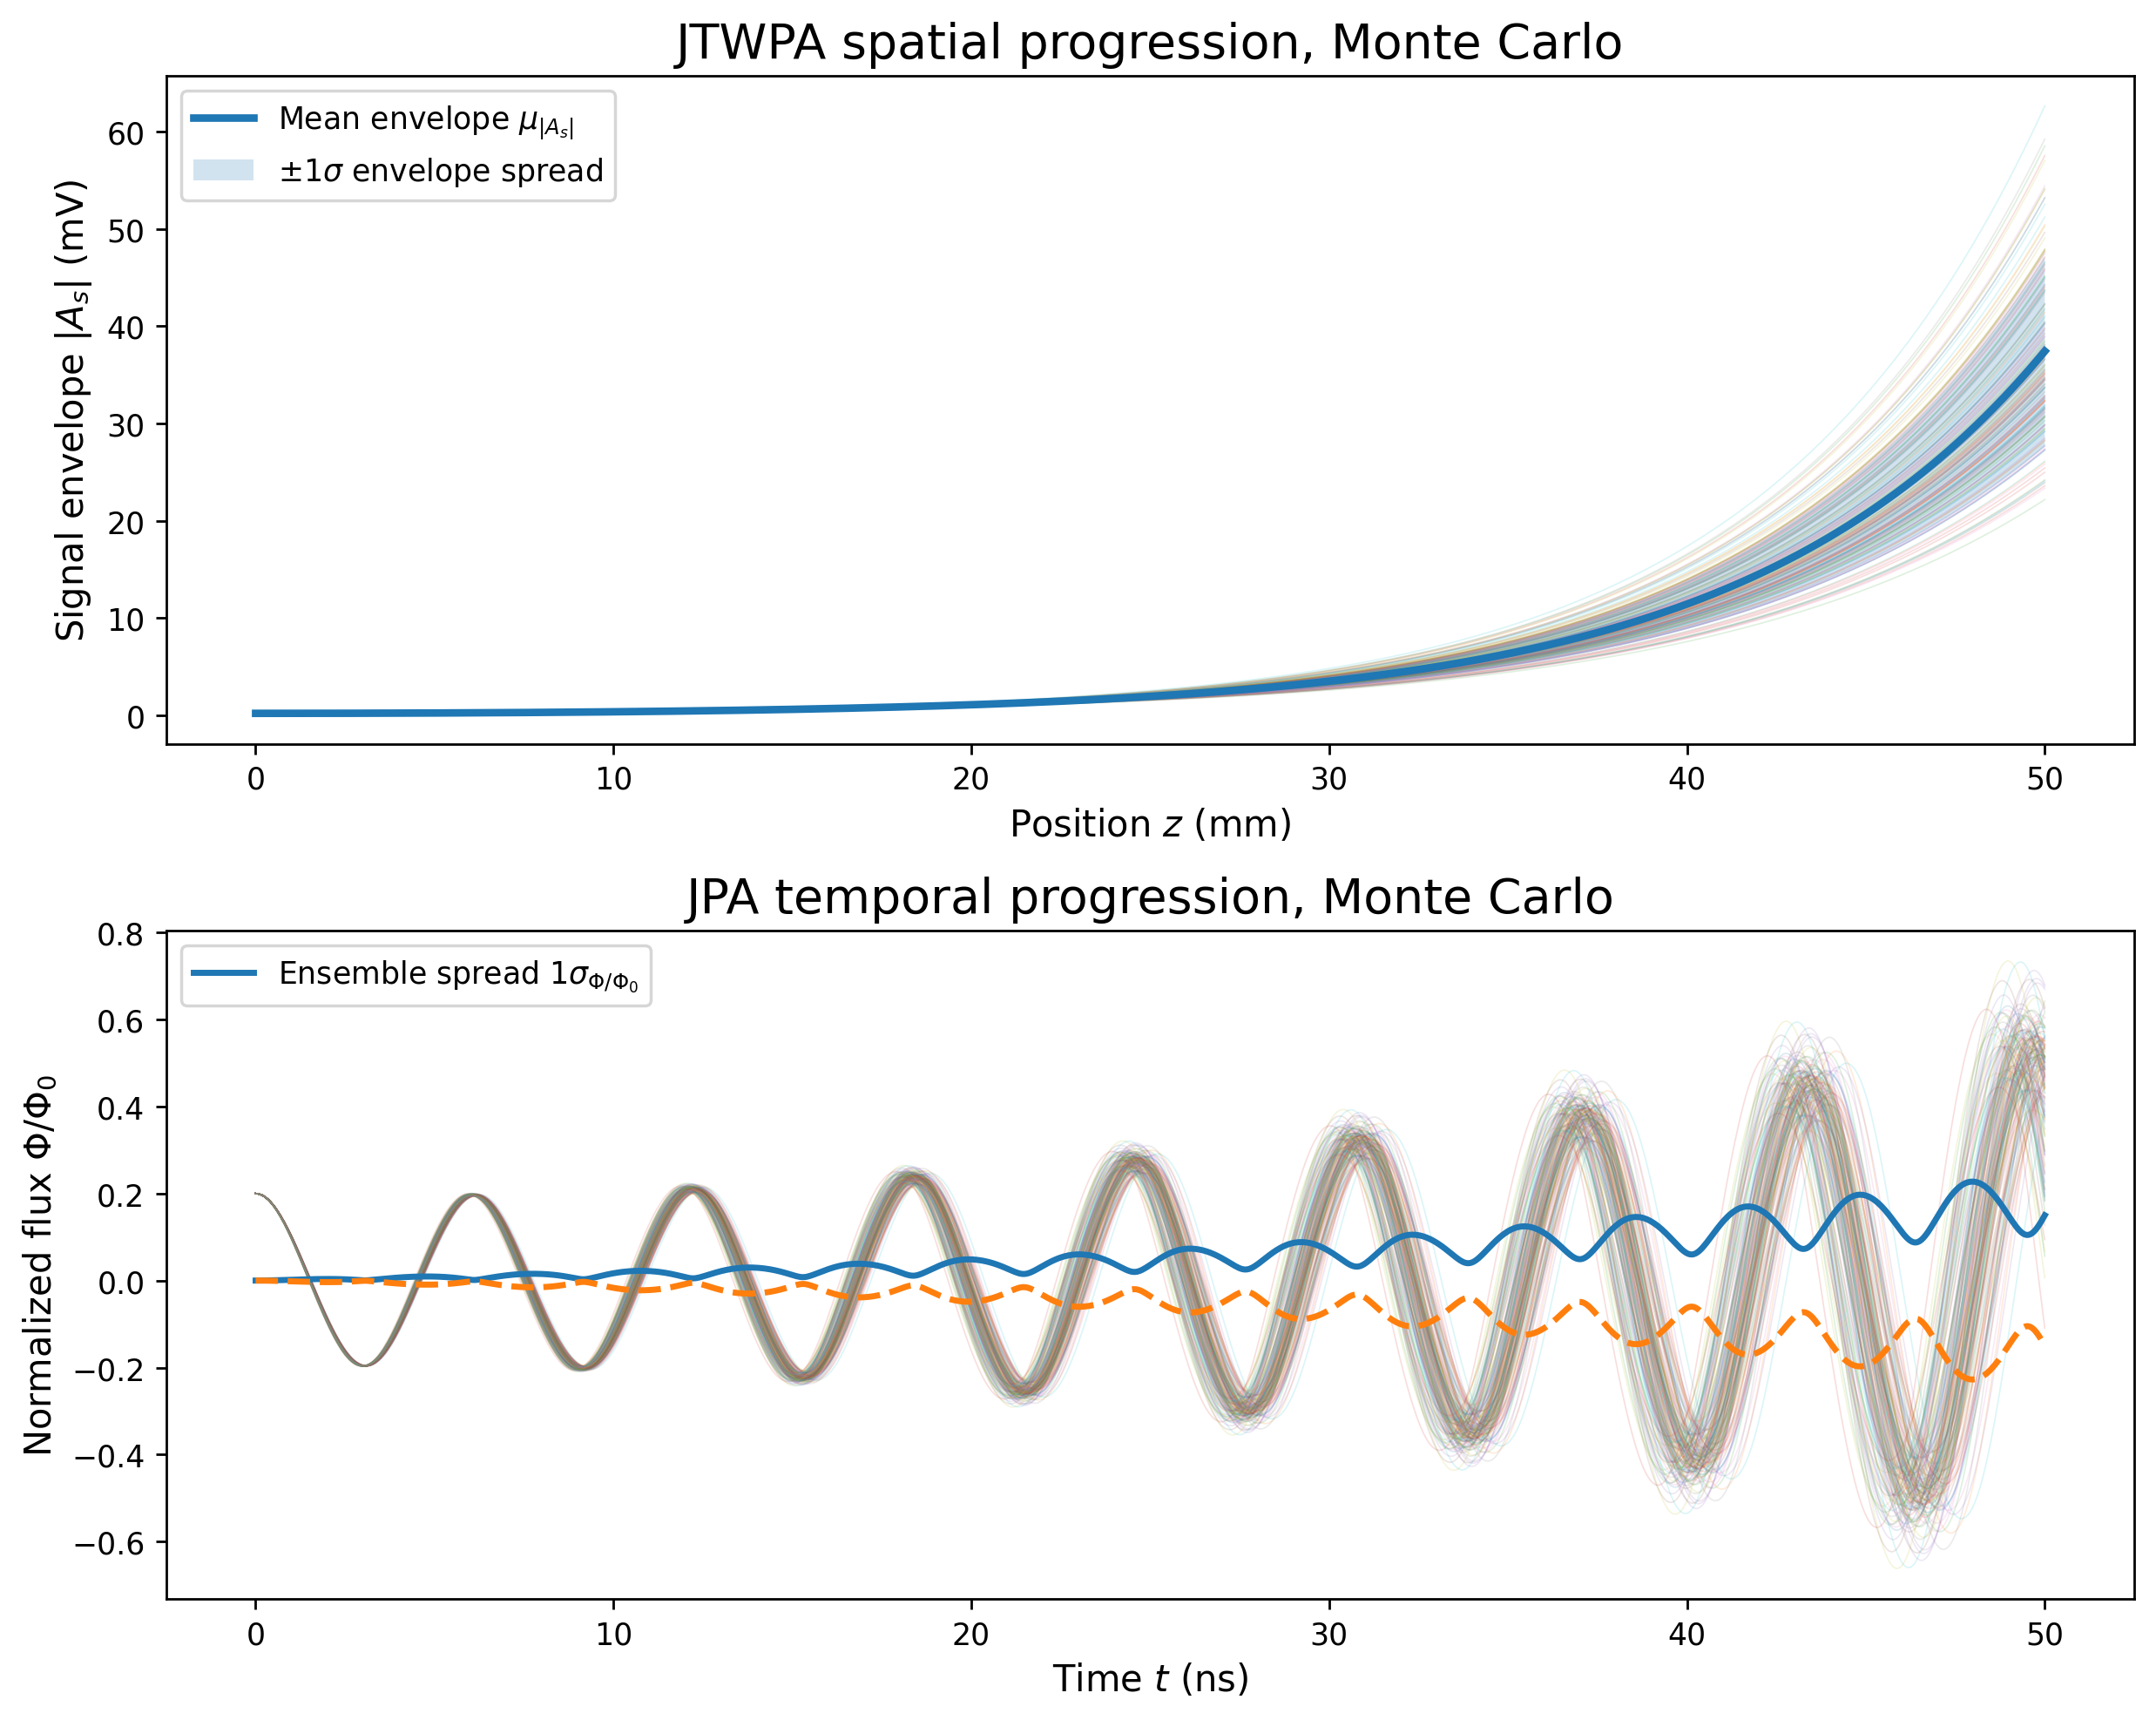

In [11]:
# !uv pip install -q torch numpy matplotlib

"""
GPU-accelerated Monte Carlo simulation of parametric amplifiers.

This module executes a tensorized fourth-order Runge-Kutta integration for
two superconducting parametric amplifier models.

Unit conventions
----------------
JTWPA:
    Position is measured in millimeters.
    Coupling strength and phase mismatch are measured per millimeter.
    Signal and idler amplitudes are measured in millivolts.

JPA:
    Time is measured in nanoseconds.
    Angular frequency is measured in radians per nanosecond.
    Damping rate is measured per nanosecond.
    Flux is normalized to the superconducting flux quantum Phi_0.

Monte Carlo controls:
    Distribution means and standard deviations use the same units as the
    corresponding physical parameter.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch


# =============================================================================
# CONTROL KNOBS WITH UNITS
# =============================================================================

# Hardware acceleration controls
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Monte Carlo and numerical integration controls
MONTE_CARLO_SAMPLES = 5_000
INTEGRATION_STEPS = 1_000
SUBSET_TRACE_LIMIT = 150
TORCH_REAL_DTYPE = torch.float32
TORCH_COMPLEX_DTYPE = torch.complex64

# Plot controls
MPL_DPI = 250
FIGURE_SIZE_IN = (10.0, 8.0)
TRACE_LINE_WIDTH_PT = 0.5
MEAN_LINE_WIDTH_PT = 2.5
RMS_LINE_WIDTH_PT = 2.0
TRACE_ALPHA = 0.15
SPREAD_ALPHA = 0.20

# JTWPA spatial-domain controls
JTWPA_LENGTH_MM = 50.0
JTWPA_KAPPA_MEAN_PER_MM = 0.12
JTWPA_KAPPA_STD_PER_MM = 0.005
JTWPA_DELTA_K_MEAN_RAD_PER_MM = 0.05
JTWPA_DELTA_K_STD_RAD_PER_MM = 0.005
JTWPA_SIGNAL_INIT_MV = 0.2
JTWPA_IDLER_CONJ_INIT_MV = 0.0
JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM = 2.0

# JPA temporal-domain controls
JPA_DURATION_NS = 50.0
JPA_OMEGA_0_MEAN_RAD_PER_NS = 1.0
JPA_OMEGA_0_STD_RAD_PER_NS = 0.01
JPA_DAMPING_RATE_PER_NS = 0.02
JPA_MODULATION_DEPTH_MEAN_DIMENSIONLESS = 0.15
JPA_MODULATION_DEPTH_STD_DIMENSIONLESS = 0.01
JPA_FLUX_INIT_PHI0 = 0.2
JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS = 0.0


@dataclass(frozen=True)
class JtwpaMonteCarloParameters:
    """Store unit-annotated JTWPA Monte Carlo parameters."""

    length_mm: float
    kappa_mean_per_mm: float
    kappa_std_per_mm: float
    delta_k_mean_rad_per_mm: float
    delta_k_std_rad_per_mm: float
    signal_init_mv: float
    idler_conj_init_mv: float
    carrier_wave_vector_rad_per_mm: float


@dataclass(frozen=True)
class JpaMonteCarloParameters:
    """Store unit-annotated JPA Monte Carlo parameters."""

    duration_ns: float
    omega_0_mean_rad_per_ns: float
    omega_0_std_rad_per_ns: float
    damping_rate_per_ns: float
    modulation_depth_mean_dimensionless: float
    modulation_depth_std_dimensionless: float
    flux_init_phi0: float
    flux_derivative_init_phi0_per_ns: float


def configure_matplotlib() -> None:
    """Apply high-resolution plotting defaults."""

    mpl.rcParams.update(
        {
            "figure.dpi": MPL_DPI,
            "font.sans-serif": ["Tahoma", "DejaVu Sans"],
            "font.weight": "normal",
            "axes.titleweight": "normal",
            "axes.titlesize": 16,
            "axes.labelsize": 12,
            "legend.fontsize": 10,
        }
    )


def print_backend_summary() -> None:
    """Print the selected PyTorch backend."""

    print(f"PyTorch device: {DEVICE}")
    if DEVICE.type == "cuda":
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")


def compute_rk4_step(
    derivative_function: Callable[..., torch.Tensor],
    independent_variable: torch.Tensor,
    state: torch.Tensor,
    step_size: float,
    *args: torch.Tensor | float,
) -> torch.Tensor:
    """
    Execute one vectorized fourth-order Runge-Kutta integration step.

    Args:
        derivative_function: Function that evaluates d(state)/d(variable).
        independent_variable: Current spatial or temporal coordinate.
        state: Current tensorized state over all Monte Carlo samples.
        step_size: Integration step size in the independent variable unit.
        *args: Additional model parameters broadcast over samples.

    Returns:
        Updated state after one RK4 step.
    """

    half_step = 0.5 * step_size

    k1 = derivative_function(independent_variable, state, *args)
    k2 = derivative_function(
        independent_variable + half_step,
        state + half_step * k1,
        *args,
    )
    k3 = derivative_function(
        independent_variable + half_step,
        state + half_step * k2,
        *args,
    )
    k4 = derivative_function(
        independent_variable + step_size,
        state + step_size * k3,
        *args,
    )

    return state + (step_size / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def evaluate_jtwpa_tensor_derivatives(
    position_mm: torch.Tensor,
    state_mv: torch.Tensor,
    kappa_per_mm: torch.Tensor,
    delta_k_rad_per_mm: torch.Tensor,
) -> torch.Tensor:
    """
    Evaluate JTWPA spatial CMT derivatives for all samples.

    Args:
        position_mm: Position along the transmission line in millimeters.
        state_mv: Tensor containing signal amplitude and conjugated idler
            amplitude in millivolts.
        kappa_per_mm: Sampled coupling strengths in inverse millimeters.
        delta_k_rad_per_mm: Sampled phase mismatches in radians per millimeter.

    Returns:
        Spatial derivatives in millivolts per millimeter.
    """

    signal_mv = state_mv[0]
    idler_conj_mv = state_mv[1]

    negative_phase = torch.exp(-1j * delta_k_rad_per_mm * position_mm)
    positive_phase = torch.exp(1j * delta_k_rad_per_mm * position_mm)

    signal_derivative_mv_per_mm = (
        1j * kappa_per_mm * idler_conj_mv * negative_phase
    )
    idler_conj_derivative_mv_per_mm = (
        -1j * kappa_per_mm * signal_mv * positive_phase
    )

    return torch.stack(
        [
            signal_derivative_mv_per_mm,
            idler_conj_derivative_mv_per_mm,
        ]
    )


def run_jtwpa_monte_carlo(
    params: JtwpaMonteCarloParameters,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the tensorized JTWPA Monte Carlo simulation.

    Args:
        params: Unit-annotated JTWPA Monte Carlo parameters.

    Returns:
        Position grid in millimeters, sample envelopes in millivolts, mean
        envelope in millivolts, and one-standard-deviation spread in
        millivolts.
    """

    kappa_samples_per_mm = torch.normal(
        mean=params.kappa_mean_per_mm,
        std=params.kappa_std_per_mm,
        size=(MONTE_CARLO_SAMPLES,),
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )
    delta_k_samples_rad_per_mm = torch.normal(
        mean=params.delta_k_mean_rad_per_mm,
        std=params.delta_k_std_rad_per_mm,
        size=(MONTE_CARLO_SAMPLES,),
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )

    position_mm = torch.linspace(
        0.0,
        params.length_mm,
        INTEGRATION_STEPS,
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )
    position_step_mm = params.length_mm / (INTEGRATION_STEPS - 1)

    initial_state_mv = torch.tensor(
        [
            complex(params.signal_init_mv, 0.0),
            complex(params.idler_conj_init_mv, 0.0),
        ],
        dtype=TORCH_COMPLEX_DTYPE,
        device=DEVICE,
    )
    state_mv = initial_state_mv.unsqueeze(1).repeat(1, MONTE_CARLO_SAMPLES)

    signal_history_mv = torch.zeros(
        (INTEGRATION_STEPS, MONTE_CARLO_SAMPLES),
        dtype=TORCH_COMPLEX_DTYPE,
        device=DEVICE,
    )

    for step_index, position_value_mm in enumerate(position_mm):
        signal_history_mv[step_index] = state_mv[0]
        state_mv = compute_rk4_step(
            evaluate_jtwpa_tensor_derivatives,
            position_value_mm,
            state_mv,
            position_step_mm,
            kappa_samples_per_mm,
            delta_k_samples_rad_per_mm,
        )

    position_cpu_mm = position_mm.detach().cpu().numpy()
    envelope_samples_mv = torch.abs(signal_history_mv).detach().cpu().numpy()
    mean_envelope_mv = np.mean(envelope_samples_mv, axis=1)
    std_envelope_mv = np.std(envelope_samples_mv, axis=1)

    return (
        position_cpu_mm,
        envelope_samples_mv,
        mean_envelope_mv,
        std_envelope_mv,
    )


def evaluate_jpa_tensor_derivatives(
    time_ns: torch.Tensor,
    state: torch.Tensor,
    omega_0_rad_per_ns: torch.Tensor,
    damping_rate_per_ns: float,
    modulation_depth_dimensionless: torch.Tensor,
) -> torch.Tensor:
    """
    Evaluate JPA temporal derivatives for all Monte Carlo samples.

    Args:
        time_ns: Time in nanoseconds.
        state: Tensor containing normalized flux Phi/Phi_0 and normalized
            flux derivative in Phi_0 per nanosecond.
        omega_0_rad_per_ns: Sampled resonant angular frequencies in radians
            per nanosecond.
        damping_rate_per_ns: Damping rate in inverse nanoseconds.
        modulation_depth_dimensionless: Sampled fractional modulation depths.

    Returns:
        Time derivatives of the normalized flux and normalized flux velocity.
        The first row has units of Phi_0 per nanosecond, while the second row
        has units of Phi_0 per square nanosecond.
    """

    flux_phi0 = state[0]
    flux_derivative_phi0_per_ns = state[1]

    pump_factor = 1.0 + modulation_depth_dimensionless * torch.cos(
        2.0 * omega_0_rad_per_ns * time_ns
    )

    flux_second_derivative_phi0_per_ns2 = (
        -damping_rate_per_ns * flux_derivative_phi0_per_ns
        - omega_0_rad_per_ns**2 * pump_factor * flux_phi0
    )

    return torch.stack(
        [
            flux_derivative_phi0_per_ns,
            flux_second_derivative_phi0_per_ns2,
        ]
    )


def run_jpa_monte_carlo(
    params: JpaMonteCarloParameters,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the tensorized JPA Monte Carlo simulation.

    Args:
        params: Unit-annotated JPA Monte Carlo parameters.

    Returns:
        Time grid in nanoseconds, sampled normalized flux histories, and the
        ensemble standard deviation of normalized flux.
    """

    omega_0_samples_rad_per_ns = torch.normal(
        mean=params.omega_0_mean_rad_per_ns,
        std=params.omega_0_std_rad_per_ns,
        size=(MONTE_CARLO_SAMPLES,),
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )
    modulation_depth_samples = torch.normal(
        mean=params.modulation_depth_mean_dimensionless,
        std=params.modulation_depth_std_dimensionless,
        size=(MONTE_CARLO_SAMPLES,),
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )

    time_ns = torch.linspace(
        0.0,
        params.duration_ns,
        INTEGRATION_STEPS,
        device=DEVICE,
        dtype=TORCH_REAL_DTYPE,
    )
    time_step_ns = params.duration_ns / (INTEGRATION_STEPS - 1)

    initial_state = torch.tensor(
        [
            params.flux_init_phi0,
            params.flux_derivative_init_phi0_per_ns,
        ],
        dtype=TORCH_REAL_DTYPE,
        device=DEVICE,
    )
    state = initial_state.unsqueeze(1).repeat(1, MONTE_CARLO_SAMPLES)

    flux_history_phi0 = torch.zeros(
        (INTEGRATION_STEPS, MONTE_CARLO_SAMPLES),
        dtype=TORCH_REAL_DTYPE,
        device=DEVICE,
    )

    for step_index, time_value_ns in enumerate(time_ns):
        flux_history_phi0[step_index] = state[0]
        state = compute_rk4_step(
            evaluate_jpa_tensor_derivatives,
            time_value_ns,
            state,
            time_step_ns,
            omega_0_samples_rad_per_ns,
            params.damping_rate_per_ns,
            modulation_depth_samples,
        )

    time_cpu_ns = time_ns.detach().cpu().numpy()
    flux_samples_phi0 = flux_history_phi0.detach().cpu().numpy()
    flux_std_phi0 = np.std(flux_samples_phi0, axis=1)

    return time_cpu_ns, flux_samples_phi0, flux_std_phi0


def plot_monte_carlo_results(
    position_mm: np.ndarray,
    envelope_samples_mv: np.ndarray,
    mean_envelope_mv: np.ndarray,
    std_envelope_mv: np.ndarray,
    time_ns: np.ndarray,
    flux_samples_phi0: np.ndarray,
    flux_std_phi0: np.ndarray,
) -> None:
    """
    Plot JTWPA and JPA Monte Carlo simulation results.

    Args:
        position_mm: Position grid in millimeters.
        envelope_samples_mv: JTWPA sample envelopes in millivolts.
        mean_envelope_mv: Mean JTWPA envelope in millivolts.
        std_envelope_mv: JTWPA standard deviation in millivolts.
        time_ns: Time grid in nanoseconds.
        flux_samples_phi0: JPA normalized flux sample histories.
        flux_std_phi0: JPA normalized flux standard deviation.
    """

    figure, (axis_jtwpa, axis_jpa) = plt.subplots(
        2,
        1,
        figsize=FIGURE_SIZE_IN,
    )

    axis_jtwpa.plot(
        position_mm,
        envelope_samples_mv[:, :SUBSET_TRACE_LIMIT],
        linewidth=TRACE_LINE_WIDTH_PT,
        alpha=TRACE_ALPHA,
    )
    axis_jtwpa.plot(
        position_mm,
        mean_envelope_mv,
        linewidth=MEAN_LINE_WIDTH_PT,
        label=r"Mean envelope $\mu_{|A_s|}$",
    )
    axis_jtwpa.fill_between(
        position_mm,
        mean_envelope_mv - std_envelope_mv,
        mean_envelope_mv + std_envelope_mv,
        alpha=SPREAD_ALPHA,
        label=r"$\pm 1\sigma$ envelope spread",
    )
    axis_jtwpa.set_xlabel(r"Position $z$ (mm)")
    axis_jtwpa.set_ylabel(r"Signal envelope $|A_s|$ (mV)")
    axis_jtwpa.set_title("JTWPA spatial progression, Monte Carlo")
    axis_jtwpa.legend(loc="upper left")
    axis_jtwpa.grid(False)

    axis_jpa.plot(
        time_ns,
        flux_samples_phi0[:, :SUBSET_TRACE_LIMIT],
        linewidth=TRACE_LINE_WIDTH_PT,
        alpha=TRACE_ALPHA,
    )
    axis_jpa.plot(
        time_ns,
        flux_std_phi0,
        linewidth=RMS_LINE_WIDTH_PT,
        label=r"Ensemble spread $1\sigma_{\Phi/\Phi_0}$",
    )
    axis_jpa.plot(
        time_ns,
        -flux_std_phi0,
        linewidth=RMS_LINE_WIDTH_PT,
        linestyle="--",
    )
    axis_jpa.set_xlabel(r"Time $t$ (ns)")
    axis_jpa.set_ylabel(r"Normalized flux $\Phi/\Phi_0$")
    axis_jpa.set_title("JPA temporal progression, Monte Carlo")
    axis_jpa.legend(loc="upper left")
    axis_jpa.grid(False)

    figure.tight_layout()
    plt.show()


def main() -> None:
    """Run unit-annotated JTWPA and JPA Monte Carlo simulations."""

    configure_matplotlib()
    print_backend_summary()

    jtwpa_params = JtwpaMonteCarloParameters(
        length_mm=JTWPA_LENGTH_MM,
        kappa_mean_per_mm=JTWPA_KAPPA_MEAN_PER_MM,
        kappa_std_per_mm=JTWPA_KAPPA_STD_PER_MM,
        delta_k_mean_rad_per_mm=JTWPA_DELTA_K_MEAN_RAD_PER_MM,
        delta_k_std_rad_per_mm=JTWPA_DELTA_K_STD_RAD_PER_MM,
        signal_init_mv=JTWPA_SIGNAL_INIT_MV,
        idler_conj_init_mv=JTWPA_IDLER_CONJ_INIT_MV,
        carrier_wave_vector_rad_per_mm=(
            JTWPA_CARRIER_WAVE_VECTOR_RAD_PER_MM
        ),
    )

    jpa_params = JpaMonteCarloParameters(
        duration_ns=JPA_DURATION_NS,
        omega_0_mean_rad_per_ns=JPA_OMEGA_0_MEAN_RAD_PER_NS,
        omega_0_std_rad_per_ns=JPA_OMEGA_0_STD_RAD_PER_NS,
        damping_rate_per_ns=JPA_DAMPING_RATE_PER_NS,
        modulation_depth_mean_dimensionless=(
            JPA_MODULATION_DEPTH_MEAN_DIMENSIONLESS
        ),
        modulation_depth_std_dimensionless=(
            JPA_MODULATION_DEPTH_STD_DIMENSIONLESS
        ),
        flux_init_phi0=JPA_FLUX_INIT_PHI0,
        flux_derivative_init_phi0_per_ns=(
            JPA_FLUX_DERIVATIVE_INIT_PHI0_PER_NS
        ),
    )

    (
        position_mm,
        envelope_samples_mv,
        mean_envelope_mv,
        std_envelope_mv,
    ) = run_jtwpa_monte_carlo(jtwpa_params)

    (
        time_ns,
        flux_samples_phi0,
        flux_std_phi0,
    ) = run_jpa_monte_carlo(jpa_params)

    plot_monte_carlo_results(
        position_mm=position_mm,
        envelope_samples_mv=envelope_samples_mv,
        mean_envelope_mv=mean_envelope_mv,
        std_envelope_mv=std_envelope_mv,
        time_ns=time_ns,
        flux_samples_phi0=flux_samples_phi0,
        flux_std_phi0=flux_std_phi0,
    )


if __name__ == "__main__":
    main()